In [ ]:
from __future__ import print_function
from tensorflow import keras
import numpy as np
from six.moves import range
from matplotlib import pyplot as plt

# Generate Dataset

In [ ]:
# Parameters for the model and dataset.
DIGITS = 3
TRAINING_SIZE = 50000
REVERSE = False

In [ ]:
class CharacterTable(object):

    def __init__(self, chars):
        self.chars = sorted(set(chars))
        self.char_indices = dict((c, i) for i, c in enumerate(self.chars))
        self.indices_char = dict((i, c) for i, c in enumerate(self.chars))

    def encode(self, C, num_rows):
        x = np.zeros((num_rows, len(self.chars)))
        for i, c in enumerate(C):
            x[i, self.char_indices[c]] = 1
        return x

    def decode(self, x, calc_argmax=True):
        if calc_argmax:
            x = x.argmax(axis=-1)
        return ''.join(self.indices_char[x] for x in x)


class colors:
    ok = '\033[92m'
    fail = '\033[91m'
    close = '\033[0m'

MAXLEN = DIGITS + 1 + DIGITS

chars = '0123456789+ '
ctable = CharacterTable(chars)

questions = []
expected = []
seen = set()
print('Generating data...')
while len(questions) < TRAINING_SIZE:
    f = lambda: int(''.join(np.random.choice(list('0123456789'))
                    for i in range(np.random.randint(1, DIGITS + 1))))
    a, b = f(), f()
    key = tuple(sorted((a, b)))
    if key in seen:
        continue
    seen.add(key)

    q = '{}+{}'.format(a, b)
    query = q + ' ' * (MAXLEN - len(q))
    ans = str(a + b)

    ans += ' ' * (DIGITS + 1 - len(ans))

    if REVERSE:
        query = query[::-1]

    questions.append(query)
    expected.append(ans)

print('Total addition questions:', len(questions))

print('Vectorization...')
x = np.zeros((len(questions), MAXLEN, len(chars)), dtype=np.bool)
y = np.zeros((len(questions), DIGITS + 1, len(chars)), dtype=np.bool)
for i, sentence in enumerate(questions):
    x[i] = ctable.encode(sentence, MAXLEN)
for i, sentence in enumerate(expected):
    y[i] = ctable.encode(sentence, DIGITS + 1)

# Shuffle
indices = np.arange(len(y))
np.random.shuffle(indices)
x = x[indices]
y = y[indices]

# Explicitly set apart 10% for validation data that we never train over.
split_at = len(x) - len(x) // 10
(x_train, x_val) = x[:split_at], x[split_at:]
(y_train, y_val) = y[:split_at], y[split_at:]

print('Training Data:')
print(x_train.shape)
print(y_train.shape)

print('Validation Data:')
print(x_val.shape)
print(y_val.shape)

Generating data...
Total addition questions: 50000
Vectorization...
Training Data:
(45000, 7, 12)
(45000, 4, 12)
Validation Data:
(5000, 7, 12)
(5000, 4, 12)


In [ ]:
y_train.shape

(45000, 4, 12)

In [ ]:
for i in range(10):
    print('{} => {}'.format(questions[i], expected[i]))

199+3   => 202 
28+61   => 89  
3+7     => 10  
29+2    => 31  
3+3     => 6   
486+7   => 493 
0+30    => 30  
3+4     => 7   
0+5     => 5   
94+841  => 935 


# Train Model

In [ ]:
RNN = keras.layers.SimpleRNN
HIDDEN_SIZE = 128
BATCH_SIZE = 128

model = keras.models.Sequential()
model.add(RNN(HIDDEN_SIZE, input_shape=(MAXLEN, len(chars))))
model.add(keras.layers.RepeatVector(DIGITS + 1))
model.add(RNN(HIDDEN_SIZE*2, return_sequences=True))
model.add(keras.layers.Dense(len(chars), activation='softmax'))


model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

model.summary()

Build model...
Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
simple_rnn (SimpleRNN)       (None, 128)               18048     
_________________________________________________________________
repeat_vector (RepeatVector) (None, 4, 128)            0         
_________________________________________________________________
simple_rnn_1 (SimpleRNN)     (None, 4, 256)            98560     
_________________________________________________________________
dense (Dense)                (None, 4, 12)             3084      
Total params: 119,692
Trainable params: 119,692
Non-trainable params: 0
_________________________________________________________________



--------------------------------------------------
Iteration 1
352/352 [==============================] - 6s 11ms/step - loss: 1.7981 - accuracy: 0.3543 - val_loss: 1.5289 - val_accuracy: 0.4371


/usr/local/lib/python3.7/dist-packages/tensorflow/python/keras/engine/sequential.py:450: UserWarning: `model.predict_classes()` is deprecated and will be removed after 2021-01-01. Please use instead:* `np.argmax(model.predict(x), axis=-1)`,   if your model does multi-class classification   (e.g. if it uses a `softmax` last-layer activation).* `(model.predict(x) > 0.5).astype("int32")`,   if your model does binary classification   (e.g. if it uses a `sigmoid` last-layer activation).
  warnings.warn('`model.predict_classes()` is deprecated and '


Q 538+326 T 864  ☒ 131 
Q 445+75  T 520  ☑ 520 
Q 65+150  T 215  ☒ 205 
Q 495+7   T 502  ☒ 506 
Q 388+31  T 419  ☒ 329 
Q 77+199  T 276  ☒ 164 
Q 142+59  T 201  ☒ 252 
Q 996+95  T 1091 ☒ 1666
Q 642+87  T 729  ☒ 710 
Q 17+244  T 261  ☒ 298 

--------------------------------------------------
Iteration 2
352/352 [==============================] - 4s 10ms/step - loss: 1.4189 - accuracy: 0.4742 - val_loss: 1.3114 - val_accuracy: 0.5132
Q 281+675 T 956  ☒ 177 
Q 469+8   T 477  ☒ 467 
Q 970+88  T 1058 ☒ 1075
Q 24+642  T 666  ☒ 677 
Q 429+91  T 520  ☒ 423 
Q 321+512 T 833  ☒ 884 
Q 236+76  T 312  ☒ 209 
Q 637+34  T 671  ☒ 778 
Q 22+19   T 41   ☒ 10  
Q 37+57   T 94   ☒ 11  

--------------------------------------------------
Iteration 3
352/352 [==============================] - 3s 10ms/step - loss: 1.1972 - accuracy: 0.5486 - val_loss: 1.1110 - val_accuracy: 0.5712
Q 94+307  T 401  ☒ 402 
Q 6+795   T 801  ☒ 793 
Q 633+17  T 650  ☒ 651 
Q 76+772  T 848  ☒ 858 
Q 135+16  T 151  ☒ 100 
Q 516+97

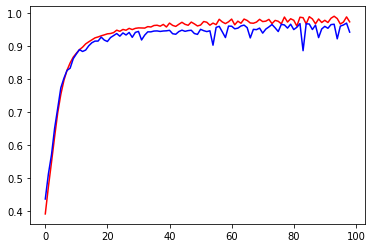

In [ ]:
train_acc = []
valid_acc = []

for iteration in range(1, 100):
    print()
    print('-' * 50)
    print('Iteration', iteration)
    history = model.fit(x_train, y_train,
                        batch_size=BATCH_SIZE,
                        epochs=1,
                        validation_data=(x_val, y_val))

    train_acc.append(history.history['accuracy'])
    valid_acc.append(history.history['val_accuracy'])


    # Select 10 samples from the validation set at random so we can visualize
    # errors.
    for i in range(10):
        ind = np.random.randint(0, len(x_val))
        rowx, rowy = x_val[np.array([ind])], y_val[np.array([ind])]
        preds = model.predict_classes(rowx, verbose=0)
        q = ctable.decode(rowx[0])
        correct = ctable.decode(rowy[0])
        guess = ctable.decode(preds[0], calc_argmax=False)
        print('Q', q[::-1] if REVERSE else q, end=' ')
        print('T', correct, end=' ')
        if correct == guess:
            print(colors.ok + '☑' + colors.close, end=' ')
        else:
            print(colors.fail + '☒' + colors.close, end=' ')
        print(guess)

plt.plot(train_acc, 'r')
plt.plot(valid_acc, 'b')
plt.show()

# Longer Sequences

## Generate Dataset

In [ ]:
# Parameters for the model and dataset.
DIGITS = 6
TRAINING_SIZE = 1000000
REVERSE = False

In [ ]:
class CharacterTable(object):

    def __init__(self, chars):
        self.chars = sorted(set(chars))
        self.char_indices = dict((c, i) for i, c in enumerate(self.chars))
        self.indices_char = dict((i, c) for i, c in enumerate(self.chars))

    def encode(self, C, num_rows):
        x = np.zeros((num_rows, len(self.chars)))
        for i, c in enumerate(C):
            x[i, self.char_indices[c]] = 1
        return x

    def decode(self, x, calc_argmax=True):
        probability, defaults to `True`.



        """
class colors:
    ok = '\033[92m'
    fail = '\033[91m'
    close = '\033[0m'

# Maximum length of input is 'int + int' (e.g., '345+678'). Maximum length of
# int is DIGITS.
MAXLEN = DIGITS + 1 + DIGITS

# All the numbers, plus sign and space for padding.
chars = '0123456789+ '
ctable = CharacterTable(chars)

questions = []
expected = []
seen = set()
print('Generating data...')
while len(questions) < TRAINING_SIZE:
    f = lambda: int(''.join(np.random.choice(list('0123456789'))
                    for i in range(np.random.randint(1, DIGITS + 1))))
    a, b = f(), f()
    # Skip any addition questions we've already seen
    # Also skip any such that x+Y == Y+x (hence the sorting).
    key = tuple(sorted((a, b)))
    if key in seen:
        continue
    seen.add(key)
    # Pad the data with spaces such that it is always MAXLEN.
    q = '{}+{}'.format(a, b)
    query = q + ' ' * (MAXLEN - len(q))
    ans = str(a + b)
    # Answers can be of maximum size DIGITS + 1.
    ans += ' ' * (DIGITS + 1 - len(ans))
    if REVERSE:
        # Reverse the query, e.g., '12+345  ' becomes '  543+21'. (Note the
        # space used for padding.)
        query = query[::-1]
    questions.append(query)
    expected.append(ans)
print('Total addition questions:', len(questions))

print('Vectorization...')
x = np.zeros((len(questions), MAXLEN, len(chars)), dtype=np.bool)
y = np.zeros((len(questions), DIGITS + 1, len(chars)), dtype=np.bool)
for i, sentence in enumerate(questions):
    x[i] = ctable.encode(sentence, MAXLEN)
for i, sentence in enumerate(expected):
    y[i] = ctable.encode(sentence, DIGITS + 1)

# Shuffle (x, y) in unison as the later parts of x will almost all be larger
# digits.
indices = np.arange(len(y))
np.random.shuffle(indices)
x = x[indices]
y = y[indices]

# Explicitly set apart 10% for validation data that we never train over.
split_at = len(x) - len(x) // 10
(x_train, x_val) = x[:split_at], x[split_at:]
(y_train, y_val) = y[:split_at], y[split_at:]

print('Training Data:')
print(x_train.shape)
print(y_train.shape)

print('Validation Data:')
print(x_val.shape)
print(y_val.shape)

Generating data...
Total addition questions: 1000000
Vectorization...
Training Data:
(900000, 13, 12)
(900000, 7, 12)
Validation Data:
(100000, 13, 12)
(100000, 7, 12)


## Training Function

In [ ]:
def train_model(RNN):
    HIDDEN_SIZE = 128
    BATCH_SIZE = 128
    LAYERS = 1

    model = keras.models.Sequential()
    model.add(RNN(HIDDEN_SIZE, input_shape=(MAXLEN, len(chars))))
    model.add(keras.layers.RepeatVector(DIGITS + 1))

    for _ in range(LAYERS):
        model.add(RNN(HIDDEN_SIZE, return_sequences=True))

    model.add(keras.layers.Dense(len(chars), activation='softmax'))


    model.compile(loss='categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

    model.summary()

    train_acc = []
    valid_acc = []
    for iteration in range(1, 100):
        print()
        print('-' * 50)
        print('Iteration', iteration)
        history = model.fit(x_train, y_train,
                            batch_size=BATCH_SIZE,
                            epochs=1,
                            verbose=2,
                            validation_data=(x_val, y_val))

        train_acc.append(history.history['accuracy'])
        valid_acc.append(history.history['val_accuracy'])

        # Select 10 samples from the validation set at random so we can visualize
        # errors.
        for i in range(10):
            ind = np.random.randint(0, len(x_val))
            rowx, rowy = x_val[np.array([ind])], y_val[np.array([ind])]
            preds = model.predict_classes(rowx, verbose=0)
            q = ctable.decode(rowx[0])
            correct = ctable.decode(rowy[0])
            guess = ctable.decode(preds[0], calc_argmax=False)
            print('Q', q[::-1] if REVERSE else q, end=' ')
            print('T', correct, end=' ')
            if correct == guess:
                print(colors.ok + '☑' + colors.close, end=' ')
            else:
                print(colors.fail + '☒' + colors.close, end=' ')
            print(guess)

    plt.plot(train_acc, 'r')
    plt.plot(valid_acc, 'b')
    plt.show()

## Simple RNN

Build model...
Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
simple_rnn_2 (SimpleRNN)     (None, 128)               18048     
_________________________________________________________________
repeat_vector_1 (RepeatVecto (None, 7, 128)            0         
_________________________________________________________________
simple_rnn_3 (SimpleRNN)     (None, 7, 128)            32896     
_________________________________________________________________
dense_1 (Dense)              (None, 7, 12)             1548      
Total params: 52,492
Trainable params: 52,492
Non-trainable params: 0
_________________________________________________________________

--------------------------------------------------
Iteration 1
7032/7032 - 92s - loss: 1.1727 - accuracy: 0.5558 - val_loss: 1.0010 - val_accuracy: 0.6145


/usr/local/lib/python3.7/dist-packages/tensorflow/python/keras/engine/sequential.py:450: UserWarning: `model.predict_classes()` is deprecated and will be removed after 2021-01-01. Please use instead:* `np.argmax(model.predict(x), axis=-1)`,   if your model does multi-class classification   (e.g. if it uses a `softmax` last-layer activation).* `(model.predict(x) > 0.5).astype("int32")`,   if your model does binary classification   (e.g. if it uses a `sigmoid` last-layer activation).
  warnings.warn('`model.predict_classes()` is deprecated and '


Q 989877+216    T 990093  ☒ 980948 
Q 1343+42       T 1385    ☒ 1371   
Q 45+573818     T 573863  ☒ 573837 
Q 2121+16644    T 18765   ☒ 18217  
Q 83+128926     T 129009  ☒ 119987 
Q 492989+76133  T 569122  ☒ 551287 
Q 76110+450477  T 526587  ☒ 622117 
Q 695263+93265  T 788528  ☒ 775217 
Q 76625+8       T 76633   ☒ 76627  
Q 8+16304       T 16312   ☒ 16308  

--------------------------------------------------
Iteration 2
7032/7032 - 90s - loss: 0.9160 - accuracy: 0.6449 - val_loss: 0.8258 - val_accuracy: 0.6780
Q 16+56733      T 56749   ☒ 56759  
Q 91+3448       T 3539    ☒ 3528   
Q 766+64490     T 65256   ☒ 65150  
Q 54237+33      T 54270   ☒ 54271  
Q 93855+55      T 93910   ☒ 93908  
Q 244842+3692   T 248534  ☒ 248568 
Q 2+5877        T 5879    ☒ 5878   
Q 5273+960      T 6233    ☒ 6220   
Q 61006+1315    T 62321   ☒ 63356  
Q 5+291450      T 291455  ☒ 291465 

--------------------------------------------------
Iteration 3
7032/7032 - 89s - loss: 0.7845 - accuracy: 0.6921 - val_loss

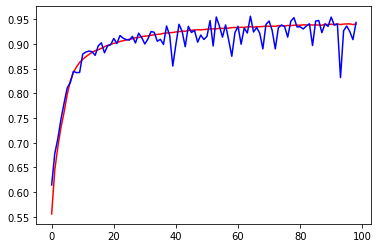

In [ ]:
train_model(keras.layers.SimpleRNN)

## LSTM

Build model...
Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
lstm (LSTM)                  (None, 128)               72192     
_________________________________________________________________
repeat_vector_1 (RepeatVecto (None, 7, 128)            0         
_________________________________________________________________
lstm_1 (LSTM)                (None, 7, 128)            131584    
_________________________________________________________________
dense_1 (Dense)              (None, 7, 12)             1548      
Total params: 205,324
Trainable params: 205,324
Non-trainable params: 0
_________________________________________________________________

--------------------------------------------------
Iteration 1
7032/7032 - 38s - loss: 1.1853 - accuracy: 0.5507 - val_loss: 0.9317 - val_accuracy: 0.6424


/usr/local/lib/python3.7/dist-packages/tensorflow/python/keras/engine/sequential.py:450: UserWarning: `model.predict_classes()` is deprecated and will be removed after 2021-01-01. Please use instead:* `np.argmax(model.predict(x), axis=-1)`,   if your model does multi-class classification   (e.g. if it uses a `softmax` last-layer activation).* `(model.predict(x) > 0.5).astype("int32")`,   if your model does binary classification   (e.g. if it uses a `sigmoid` last-layer activation).
  warnings.warn('`model.predict_classes()` is deprecated and '


Q 3+14152       T 14155   ☒ 14120  
Q 8+9771        T 9779    ☒ 9789   
Q 9+33194       T 33203   ☒ 33100  
Q 38529+298     T 38827   ☒ 38748  
Q 84386+9969    T 94355   ☒ 93288  
Q 48233+6       T 48239   ☒ 48230  
Q 58935+8795    T 67730   ☒ 64689  
Q 711+636       T 1347    ☒ 1388   
Q 10+7712       T 7722    ☒ 7725   
Q 15857+17      T 15874   ☒ 15802  

--------------------------------------------------
Iteration 2
7032/7032 - 35s - loss: 0.8396 - accuracy: 0.6743 - val_loss: 0.7483 - val_accuracy: 0.7079
Q 467+9971      T 10438   ☒ 10430  
Q 9623+5174     T 14797   ☒ 14033  
Q 7+74317       T 74324   ☑ 74324  
Q 40+488202     T 488242  ☑ 488242 
Q 995608+25     T 995633  ☒ 995543 
Q 74902+4       T 74906   ☒ 74905  
Q 457+62699     T 63156   ☒ 63043  
Q 30+497457     T 497487  ☒ 497463 
Q 67+1144       T 1211    ☒ 1200   
Q 2+74290       T 74292   ☑ 74292  

--------------------------------------------------
Iteration 3
7032/7032 - 36s - loss: 0.6429 - accuracy: 0.7487 - val_loss

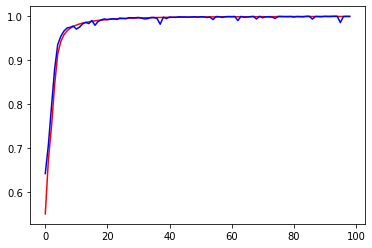

In [ ]:
train_model(keras.layers.LSTM)

## GRU

Build model...
Model: "sequential_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
gru_2 (GRU)                  (None, 128)               54528     
_________________________________________________________________
repeat_vector_2 (RepeatVecto (None, 7, 128)            0         
_________________________________________________________________
gru_3 (GRU)                  (None, 7, 128)            99072     
_________________________________________________________________
dense_2 (Dense)              (None, 7, 12)             1548      
Total params: 155,148
Trainable params: 155,148
Non-trainable params: 0
_________________________________________________________________

--------------------------------------------------
Iteration 1
7032/7032 - 36s - loss: 1.2356 - accuracy: 0.5308 - val_loss: 0.9667 - val_accuracy: 0.6274


/usr/local/lib/python3.7/dist-packages/tensorflow/python/keras/engine/sequential.py:450: UserWarning: `model.predict_classes()` is deprecated and will be removed after 2021-01-01. Please use instead:* `np.argmax(model.predict(x), axis=-1)`,   if your model does multi-class classification   (e.g. if it uses a `softmax` last-layer activation).* `(model.predict(x) > 0.5).astype("int32")`,   if your model does binary classification   (e.g. if it uses a `sigmoid` last-layer activation).
  warnings.warn('`model.predict_classes()` is deprecated and '


Q 307681+9      T 307690  ☒ 307766 
Q 791+924675    T 925466  ☒ 925161 
Q 76+42         T 118     ☒ 128    
Q 678469+397    T 678866  ☒ 678256 
Q 848216+2096   T 850312  ☒ 851161 
Q 23+74662      T 74685   ☒ 74666  
Q 19909+6       T 19915   ☒ 19906  
Q 4684+0        T 4684    ☒ 4685   
Q 65376+4215    T 69591   ☒ 60116  
Q 490+94        T 584     ☒ 586    

--------------------------------------------------
Iteration 2
7032/7032 - 33s - loss: 0.8749 - accuracy: 0.6617 - val_loss: 0.8019 - val_accuracy: 0.6884
Q 99+169861     T 169960  ☒ 169095 
Q 32251+1820    T 34071   ☒ 33061  
Q 583+934       T 1517    ☒ 1555   
Q 85605+89      T 85694   ☒ 85695  
Q 222+812066    T 812288  ☒ 812151 
Q 718099+5      T 718104  ☒ 718101 
Q 311549+61     T 311610  ☒ 311691 
Q 50998+4984    T 55982   ☒ 56611  
Q 53237+271615  T 324852  ☒ 321111 
Q 6347+696581   T 702928  ☒ 704365 

--------------------------------------------------
Iteration 3
7032/7032 - 33s - loss: 0.7095 - accuracy: 0.7244 - val_loss

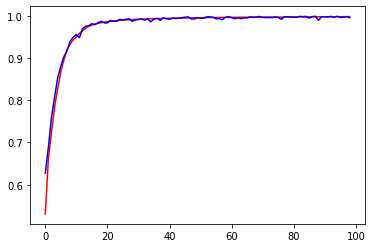

In [ ]:
train_model(keras.layers.GRU)